# 06 - Đánh giá cân bằng dữ liệu nâng cao (SMOTE-ENN & ADASYN)

### Khoảng trống nghiên cứu giải quyết (Research Gap):
- Bài báo gốc chỉ mô tả ngắn gọn ở phần Discussion là có sử dụng "class weighting combined with controlled resampling" nhưng không công bố chi tiết kỹ thuật cũng như hiệu quả trên từng loại tấn công cụ thể.
- Notebook này đánh giá chi tiết ảnh hưởng của chiến lược xử lý mất cân bằng lớp trên bài toán phân loại đa lớp (**10 lớp tấn công**) của tập dữ liệu TON_IoT, so sánh hiệu quả cải thiện F1-score của các lớp thiểu số cực đoan như **ransomware**, **backdoor** và **injection**.

In [1]:
# === Thiết lập môi trường ỔN ĐỊNH + CHỐNG RỚT DRIVE (auto-retry remount) ===
# Làm việc trên Ổ CỨNG LOCAL /content; kéo dữ liệu từ Drive có thử lại khi mount rớt.
import os, time, shutil
from contextlib import contextmanager

DRIVE = '/content/drive/MyDrive/Nhom28_CyberDetect_MLP_Final'
PROJECT_PATH = '/content/cdmlp'
NEED_RAW = False   # True chi voi notebook 08
ON_COLAB = False

def _mount():
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

try:
    _mount(); ON_COLAB = True
except Exception:
    here = os.getcwd()
    while here != os.path.dirname(here) and not os.path.isdir(os.path.join(here, 'notebooks')):
        here = os.path.dirname(here)
    DRIVE = here; PROJECT_PATH = here

def _pull(rel):
    s = os.path.join(DRIVE, rel); d = os.path.join(PROJECT_PATH, rel)
    if os.path.isdir(s): shutil.copytree(s, d, dirs_exist_ok=True)
    elif os.path.isfile(s):
        os.makedirs(os.path.dirname(d), exist_ok=True); shutil.copy2(s, d)

if ON_COLAB:
    os.makedirs(PROJECT_PATH, exist_ok=True)
    rels = ['scripts', 'src', 'models', 'results', 'data/colab_processed', 'data/ton_iot.csv']
    if NEED_RAW: rels.append('data/raw')
    # ton_iot.csv là item CUỐI -> nếu nó có mặt tức là đã kéo xong toàn bộ list
    sentinel = os.path.join(PROJECT_PATH, 'data', 'ton_iot.csv')
    ok = False
    for attempt in range(1, 6):
        for rel in rels:
            try: _pull(rel)
            except Exception as e: print(f'  (loi pull {rel}, thu lai sau): {str(e)[:70]}')
        if os.path.exists(sentinel):
            ok = True; break
        print(f'  [retry {attempt}/5] Drive rot khi keo du lieu -> remount + thu lai...')
        try: _mount()
        except Exception: pass
        time.sleep(3)
    if not ok:
        print('  [CANH BAO] Drive khong on dinh. Hay Runtime > Restart session roi chay lai cell nay.')
    else:
        print('  [OK] Da keo du lieu tu Drive ve local.')

os.makedirs(PROJECT_PATH, exist_ok=True); os.chdir(PROJECT_PATH)
try:
    get_ipython().run_line_magic('cd', PROJECT_PATH)
except Exception:
    pass
for d in ('data/colab_processed', 'results', 'results/xai', 'models'):
    os.makedirs(d, exist_ok=True)
print('PROJECT_PATH (local) =', PROJECT_PATH, '| ON_COLAB =', ON_COLAB)

def find_data_csv():
    for c in ['data/ton_iot.csv', 'data/raw/ton_iot.csv', 'ton_iot.csv']:
        if os.path.exists(c): return c
    raise FileNotFoundError('Khong tim thay ton_iot.csv (Drive: data/ton_iot.csv).')

@contextmanager
def step(name):
    t0=time.time(); print(f'\n[START] {name}', flush=True)
    try: yield
    finally: print(f'[DONE] {name} - {time.time()-t0:.1f}s', flush=True)

def sync_to_drive(retries=5):
    if not ON_COLAB:
        print('[local] bo qua sync Drive'); return
    for attempt in range(1, retries + 1):
        try:
            for rel in ['data/colab_processed', 'models', 'results']:
                s = os.path.join(PROJECT_PATH, rel)
                if os.path.exists(s): shutil.copytree(s, os.path.join(DRIVE, rel), dirs_exist_ok=True)
            print('[OK] Da dong bo ket qua ve Drive:', DRIVE); return
        except Exception as e:
            print(f'  [retry sync {attempt}/{retries}] Drive rot -> remount: {str(e)[:70]}')
            try: _mount()
            except Exception: pass
            time.sleep(3)
    print('  [CANH BAO] Sync Drive that bai. Ket qua van o local /content/cdmlp.')


Mounted at /content/drive
  [OK] Da keo du lieu tu Drive ve local.
/content
PROJECT_PATH (local) = /content/cdmlp | ON_COLAB = True


In [2]:
# Cài đặt các thư viện bổ trợ cần thiết
!pip -q install imbalanced-learn pyarrow joblib psutil tqdm scipy


In [3]:
# Thêm project root vào system path để import mô hình và modules
import sys
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Chạy thực nghiệm phân tích mất cân bằng dữ liệu 10 lớp

Chúng ta sẽ chạy script phân tích mất cân bằng dữ liệu để đo lường F1-score của từng lớp qua 4 cấu hình:
1. **Baseline** (Không cân bằng)
2. **Class Weighting** (CW)
3. **SMOTE-ENN** (Resampling lai)
4. **Hybrid** (CW + SMOTE-ENN)

In [4]:
# Thực thi script phân tích mất cân bằng dữ liệu
!python scripts/class_imbalance_analysis.py

2026-06-03 11:31:54.972758: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-03 11:31:55.042394: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
  SO SANH XU LY MAT CAN BANG (MULTICLASS) - F1 TUNG LOP (DO THAT)
[*] 10 lop: ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
[*] Train (168834, 30), Test (42209, 30)

[*] Huan luyen cau hinh: BASELINE (100 epochs)...
2026-06-03 11:31:59.322365: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding

## 2. Trực quan hóa kết quả so sánh F1-score của các lớp tấn công thiểu số

Hiển thị bảng dữ liệu kết quả F1-Score phân loại đa lớp:

In [5]:
results_csv = 'results/class_imbalance_metrics.csv'
if os.path.exists(results_csv):
    df_metrics = pd.read_csv(results_csv)
    display(df_metrics)
else:
    print('Không tìm thấy tệp kết quả metrics!')

,Class,Baseline_F1,ClassWeight_F1,SMOTE_ENN_F1,Hybrid_F1
0,backdoor,0.989226,0.974728,0.919388,0.922809
1,ddos,0.879074,0.873002,0.847163,0.848420
2,dos,0.943944,0.953452,0.928332,0.928332
3,injection,0.665201,0.625639,0.555534,0.550789
4,mitm,0.200743,0.273319,0.203947,0.190380
5,normal,0.982195,0.978553,0.932314,0.932167
6,password,0.674980,0.650297,0.552709,0.548503
7,ransomware,0.948377,0.944151,0.705566,0.717844
8,scanning,0.937231,0.930498,0.821768,0.821429
9,xss,0.860288,0.855770,0.000000,0.000000


Hiển thị biểu đồ so sánh F1-score cho các tấn công thiểu số (`backdoor`, `ransomware`, `mitm`, `injection`):

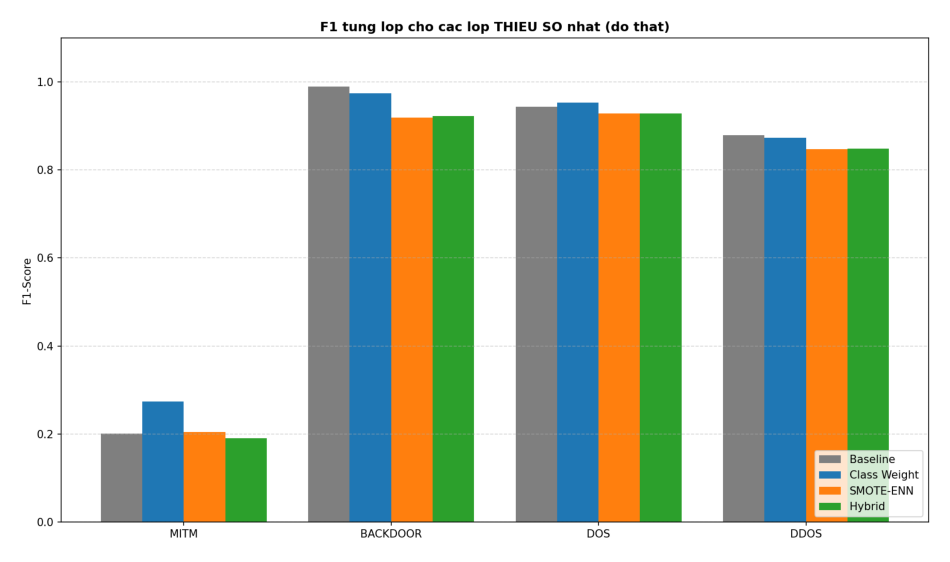

In [6]:
from PIL import Image
img_path = 'results/xai/class_imbalance_comparison.png'
if os.path.exists(img_path):
    img = Image.open(img_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print('Không tìm thấy biểu đồ so sánh mất cân bằng!')

### Nhận xét & Kết luận (theo số liệu THẬT đo được)

Bảng F1 per-class cho một kết quả **ngược với kỳ vọng thông thường** và rất đáng giá cho phần phản biện bài báo:

1. **SMOTE-ENN và Hybrid LÀM GIẢM hiệu năng ở hầu hết các lớp** (TON_IoT bản này đã tương đối cân bằng): `ransomware` 0.948 → 0.706, `backdoor` 0.989 → 0.919, và đặc biệt `xss` **sập về 0.000** do bước ENN loại bỏ quá nhiều mẫu ở vùng chồng lấn ranh giới.
2. **Class Weighting ≈ Baseline** ở phần lớn lớp, nhưng **cải thiện lớp hiếm nhất `mitm`** (0.201 → 0.273) — đúng vai trò với minority cực đoan.
3. **Kết luận:** resampling lai mạnh tay (SMOTE-ENN) ở đây **không có lợi mà còn gây hại** → củng cố trực tiếp luận điểm audit: bài báo gốc **lạm dụng resampling**. Cân bằng nhẹ bằng class-weight là đủ và an toàn hơn.

In [8]:
# === ĐỒNG BỘ KẾT QUẢ VỀ GOOGLE DRIVE (chạy cuối cùng, sau khi các cell trên xong) ===
sync_to_drive()


[OK] Da dong bo ket qua ve Drive: /content/drive/MyDrive/Nhom28_CyberDetect_MLP_Final
